In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
%matplotlib inline

I0000 00:00:1786169799.405151    9651 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786169806.365089    9651 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786169814.559226    9651 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data() # this is how we load datasets in tensoflow
# mnist is handrwitten dataset with huge collection of numbers
# there are also Fashion mnist
# CIFAR-10 for cars, cats, airplanes, ...

In [3]:
# We need to scale the data for better training
X_train = X_train / 255
X_test = X_test / 255

In [4]:
len(X_train)

60000

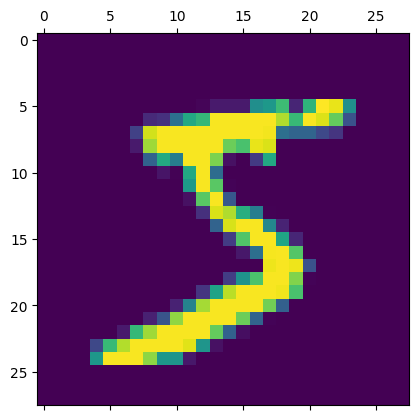

In [5]:
plt.matshow(X_train[0])

In [7]:
X_train_flattened = X_train.reshape(len(X_train), 28 * 28)
X_test_flattened = X_test.reshape(len(X_test), 28 * 28)
X_train_flattened.shape

(60000, 784)

In [8]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape = (784,), activation='sigmoid')
])
# .Dense means every input layer will connected to each output layer and define the input numbers and the output which is 10
# activation='sigmoid' will convert number into range of 0 and 1

# define how I want my model to train
model.compile( 
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [9]:
model.fit(X_train_flattened, y_train, epochs = 5) # it will repeats 9 times

W0000 00:00:1786169951.294204    9651 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8762 - loss: 0.4695
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9152 - loss: 0.3041
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9208 - loss: 0.2833
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2733
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9257 - loss: 0.2668


In [10]:
# test the model
model.evaluate(X_test_flattened, y_test) 

  1/313 ━━━━━━━━━━━━━━━━━━━━ 43s 140ms/step - accuracy: 0.9688 - loss: 0.2672

W0000 00:00:1786170063.490263    9651 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9253 - loss: 0.2666


[0.2666436433792114, 0.9253000020980835]

In [12]:
predicted = model.predict(X_test_flattened)

 21/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

W0000 00:00:1786170095.043441    9651 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
y_predicted_labels = [np.argmax(i) for i in predicted]

y_predicted_labels[:4]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0)]

In [14]:
cm = tf.math.confusion_matrix(labels=y_test, predictions = y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    1,    2,    0,    5,    4,    3,    1,    1],
       [   0, 1114,    3,    2,    0,    1,    4,    2,    9,    0],
       [   4,    9,  920,   18,    8,    5,   13,   13,   37,    5],
       [   4,    0,   19,  926,    0,   21,    2,   12,   18,    8],
       [   1,    2,    4,    2,  909,    0,   10,    5,    7,   42],
       [  10,    3,    3,   37,    9,  776,   12,    8,   26,    8],
       [  10,    3,    6,    2,    7,   16,  910,    2,    2,    0],
       [   1,    5,   22,    5,    4,    0,    0,  957,    3,   31],
       [   6,    8,    6,   26,    9,   32,    8,   13,  854,   12],
       [  10,    7,    1,    9,   22,    6,    0,   26,    4,  924]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

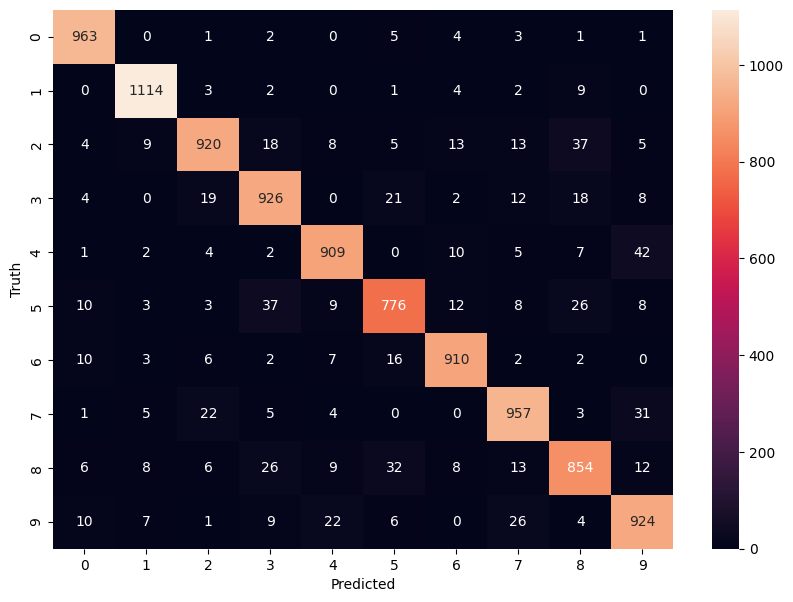

In [15]:
import seaborn as sns

plt.figure(figsize= (10, 7))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')